# Dimuon data from NANOAOD

**CMS Open Data Workshop & Pedagogy Hackathon 2026**
[Workshop website](https://cms-opendata-workshop.github.io/2026July-NotreDame/) | [Indico page](https://indico.cern.ch/event/1672496/)


## Introduction and motivation

**Q**: What's all this about? 

**A**: This notebook is about how to use open data from the [CMS Experiment](https://cms.cern) at the LHC. Specifically, we will use a two-muon dataset in the NANOAOD format.

What we cover here:
* What's in the CMS NANOAOD format and how to use it
* How to make some simple selections on the data and plot results

**NOTE:** If you are running this in Google Colab run the following command:

In [ ]:
!pip install -r https://raw.githubusercontent.com/cms-opendata-workshop/workshop2026-lesson-dimuon-from-nanoaod/main/requirements.txt

## CMS Open Data and double muon events

There are over 4PB of real and simulated data from CMS available. We will certainly not need it all to do something interesting. 

Let's look at events which have been selected out because they have at least 2 muons. If we visualized one of the events it would look something like this:

![dimuon](imgs/doublemuon.png)

Where the muon trajectories are represented by the long red lines.

## Exploring the data: the CMS NANOAOD format

Recall that each CMS dataset is associated to a record on the CERN Open Data Portal. We will select a DoubleMuon NANOAOD dataset:

[DoubleMuon primary dataset in NANOAOD format from RunH of 2016](https://opendata.cern.ch/record/30555)

which is record number 30555.

We'll take a relatively small file and download it locally:

In [6]:
file_name = 'EEB2FE3F-7CF3-BF4A-9F70-3F89FACE698E.root'
file_url = 'http://opendata.cern.ch/eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/EEB2FE3F-7CF3-BF4A-9F70-3F89FACE698E.root'

# If we've already downloaded the file let's not do it again. Otherwise, download it.
if not (os.path.isfile(f'{file_name}')):
    subprocess.run(['curl', '-O', f'{file_url}'])

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  262M  100  262M    0     0  30.4M      0  0:00:08  0:00:08 --:--:-- 31.7M


The NANOAOD files can of course be opened and explored using ROOT, in particular [PyROOT](https://root.cern/manual/python/). Here we'll instead use the SciKit-HEP tools [uproot](https://github.com/scikit-hep/uproot5) ("ROOT I/O in pure Python and NumPy") and [awkward](https://github.com/scikit-hep/awkward) ("Manipulate JSON-like data with NumPy-like idioms").

Here we import the required libraries:

In [7]:
import numpy as np
import matplotlib.pylab as plt
import uproot
import vector
import awkward as ak

vector.register_awkward()

Let's first open the file we've downloaded and see what's in it:

In [8]:
infile = uproot.open(file_name)

keys = infile.keys()
print(keys)

['tag;1', 'Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']


Since we're using `uproot/awkward` let's see what we have:

In [9]:
events = infile['Events']
events.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | uint32_t                 | AsDtype('>u4')
luminosityBlock      | uint32_t                 | AsDtype('>u4')
event                | uint64_t                 | AsDtype('>u8')
nboostedTau          | uint32_t                 | AsDtype('>u4')
boostedTau_charge... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_eta       | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_leadTk... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_leadTk... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_leadTk... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_mass      | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_neutra... | float[]                  | AsJagged(AsDtype('>f4'))
boostedTau_phi       | float[]                  | AsJ

What does all this mean? Recall that thankfully in the [dataset record](https://opendata.cern.ch/record/30555) there is a list of file variables (with explanations) under `Dataset semantics`. The link is [here](https://opendata.cern.ch/eos/opendata/cms/dataset-semantics/NanoAOD/30555/DoubleMuon_doc.html).

Here is what is available for muons:

![muon stuff](https://github.com/cms-dpoa/cms-acp-tutorial/blob/main/imgs/muon-variables.png?raw=1)

We can filter on the variables and load a selection of them into a data frame:

In [10]:
filter_name = '/(nMuon|Muon_pt|Muon_eta|Muon_phi|Muon_charge|Muon_mass|Muon_isGlobal)/'
df = events.arrays(filter_name=filter_name, library='ak')
df

<Array [{nMuon: 2, Muon_eta: [...], ...}, ...] type='285647 * {nMuon: uint3...'>

What's this? We basically have a structure in which we have a list objects, each object corresponding to an event. How many muons we have in each event is given by the `nMuon` variable, followed but the properties of each muon. So for example, for the first event:

In [11]:
df[0]

<Record {nMuon: 2, Muon_eta: [...], ...} type='{nMuon: uint32, Muon_eta: va...'>

We have two muons, one with a charge of -1 and a pt of 28.1 GeV, and the other with a charge of +1 and a pt of 12.1 GeV

## Simple analysis and plotting

Let's make some histograms to look at the distribution of some the the variables.
Note that we have to use `ak.flatten` to flatten the array structure before we create a histogram:

In [12]:
ak.flatten(df['Muon_eta'])

<Array [0.457, -0.934, -0.945, ..., 1.72, 1.34, 1.47] type='649323 * float32'>

First we make a 2-by-2 grid in which to add 4 plots. We will make histograms of some of the properties of the muons in the events:

Text(0.5, 0, 'muon phi')

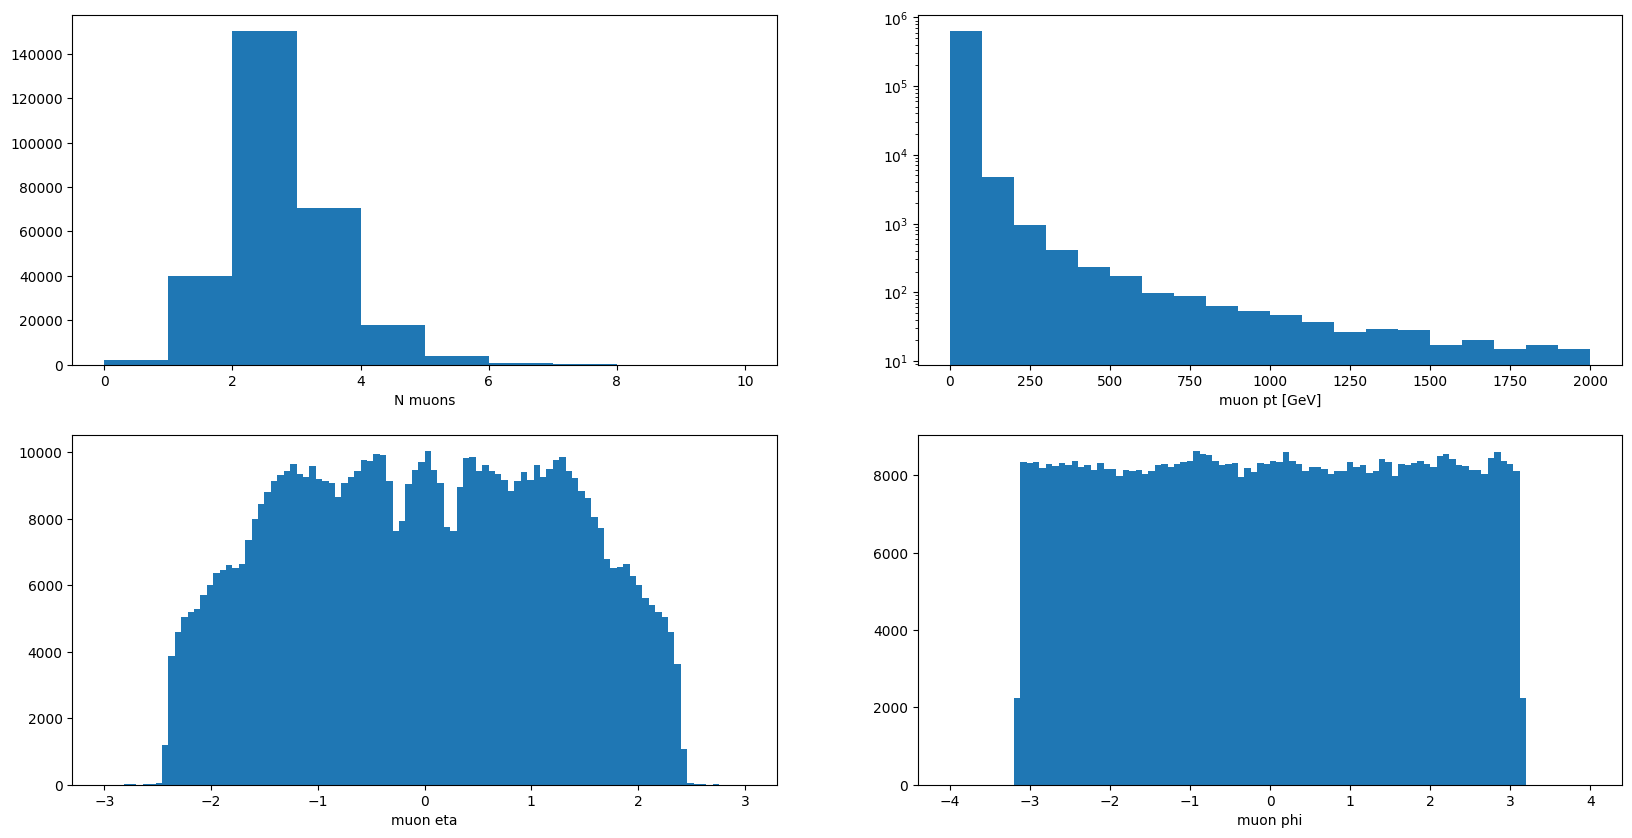

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(20,10))

axes[0][0].hist(ak.num(df['Muon_pt']), bins=10, range=(0,10))
axes[0][0].set_xlabel('N muons')

axes[0][1].hist(ak.flatten(df['Muon_pt']), bins=20, range=(0,2000))
axes[0][1].set_xlabel('muon pt [GeV]')
axes[0][1].set_yscale('log')

axes[1][0].hist(ak.flatten(df['Muon_eta']), bins=100, range=(-3,3))
axes[1][0].set_xlabel('muon eta')

axes[1][1].hist(ak.flatten(df['Muon_phi']), bins=100, range=(-4,4))
axes[1][1].set_xlabel('muon phi')

Next we will make some simple selections. We will select events with precisely 2 muons, each of which is a "global" muon (which we will use as a proxy for muon quality), and finally, requiring them to be of opposite charge.

In [14]:
muon_cut = (df['nMuon'] == 2)
print(muon_cut)

[True, True, True, False, True, True, ..., False, False, False, False, True]


What is this?

This array of booleans can be used to select for elements in the data that either fulfill (or don't) the conditions that we specified. We can see how to apply the cut below and see how many events remain.

Essentially, if `True` we keep the event, and if `False` we discard it.

In [15]:
print(
    f'{len(df)} before our selection'
)

df = df[muon_cut]

print(
    f'{len(df)} events after our selection (requiring precisely 2 muons)'
)

285647 before our selection
150096 events after our selection (requiring precisely 2 muons)


A similar selection can be done to select for "global muons" which are muons which have matching muon tracks in the tracker and in the muon detector. `Muon_isGlobal` is boolean in nature already.

In [16]:
df['Muon_isGlobal']

<Array [[True, True], [...], ..., [False, True]] type='150096 * var * bool'>

We use the `awkward.all` function to test if all of the muons in one event are global. The `axis=1` means that we look at the pairs of inner elements in the array, rather than every single muon in the collection of events (which would be `axis=0`).

In [17]:
global_cut  = ak.all(df['Muon_isGlobal'], axis=1)
print(global_cut)

[True, True, True, True, True, False, ..., True, False, True, True, True, False]


In [18]:
df = df[global_cut]

We have a data frame with two global muons. Now let's collect these muons and construct four-momenta in order to make a calcuation of the [invariant mass](https://atlas.cern/glossary/mass) of the two muons:

In [19]:
muons = ak.zip({
    'pt': df.Muon_pt,
    'phi': df.Muon_phi,
    'eta': df.Muon_eta,
    'mass': df.Muon_mass,
    'charge': df.Muon_charge,
}, with_name='Momentum4D')

We then make another selection for muons of opposite charge. Since the particles what we are looking for are neutral, then the muons that come from the decay should be of opposite charge.

In [20]:
oppsign_cut = muons[:,0].charge*muons[:,1].charge == -1
samesign_cut = muons[:,0].charge*muons[:,1].charge == 1

print(
    f'Total number of events: {len(muons)}\n',
    f'Number of events with opp-sign muons: {len(muons[oppsign_cut])}\n',
    f'Number of events with same-sign muons: {len(muons[samesign_cut])}'
)

Total number of events: 131528
 Number of events with opp-sign muons: 100687
 Number of events with same-sign muons: 30841


In [21]:
muons = muons[oppsign_cut]

We construct the invariant mass, which basically applies the formula 

$M^2 = \left(E_{1}+E_{2}\right)^2 - \left| \vec{p}_{1} + \vec{p}_{2}\right|^2$

In [22]:
M = (muons[:, 0] + muons[:, 1]).mass

We then make a histogram of the invariant mass, which is a determination of the rest mass of the particle which decayed to the two muons. It turns out that there are natural background processes that produce two muons as well. Let's see if there are any peaks (over background) in our distribution:

Text(0, 0.5, 'Number of events')

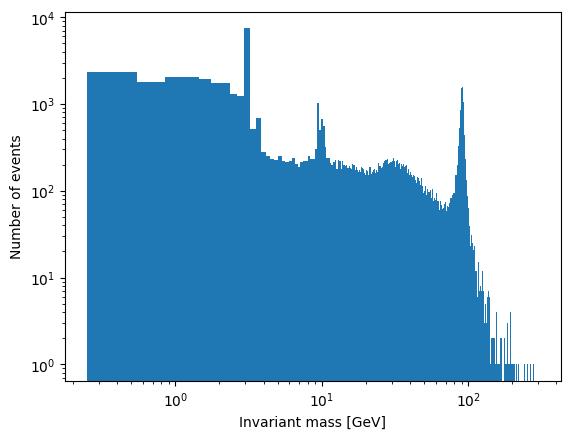

In [23]:
plt.hist(M, bins=1000, range=(0.25,300))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Invariant mass [GeV]')
plt.ylabel('Number of events')

Let's adjust how we draw this histogram and label the peaks (as it turns out that we know what they are).

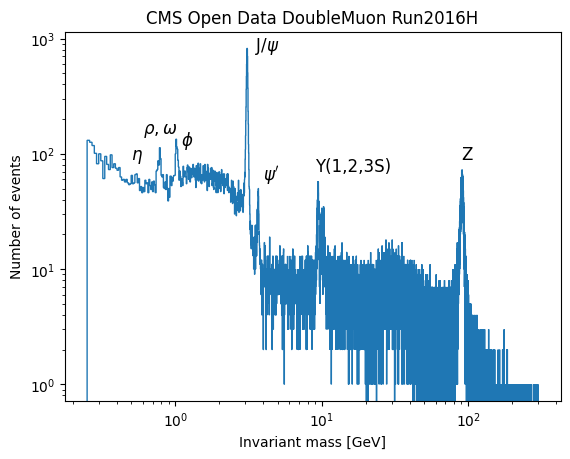

In [24]:
bins = np.linspace(0.25, 300, 30000)

counts, edges, _ = plt.hist(
    M,
    bins=bins,
    histtype='step',
    density=False
)

plt.xscale('log')
plt.yscale('log')

annotations = [
    (r"$\eta$", 0.50, 90),
    (r"$\rho,\omega$", 0.60, 150),
    (r"$\phi$", 1.10, 120),
    (r"J/$\psi$", 3.5, 800),
    (r"$\psi'$", 4.0, 60),
    (r"Y(1,2,3S)", 9.0, 70),
    (r"Z", 90.0, 90)
]

for a in annotations:
    plt.text(
        a[1], a[2], a[0],
        fontsize=12,
        color="black"
    )

plt.xlabel('Invariant mass [GeV]')
plt.ylabel('Number of events')
plt.title('CMS Open Data DoubleMuon Run2016H')
plt.show()

The peaks labelled here represent a long history of discovery and study in particle physics, from the eta meson up to the Z boson.